
### SOLUCION DESARROLLADA CON AGENTES 

# Parte A: Observación inicial
En esta sección realizaremos una primera exploración del dataset de pingüinos. El objetivo es observar la estructura de los datos, identificar las variables presentes y detectar posibles valores faltantes o inconsistencias.
Este proceso es fundamental para comprender el contexto del análisis y tomar decisiones informadas en las siguientes etapas.
A continuación, se muestra cómo cargar el dataset y realizar una observación inicial utilizando pandas.

In [1]:
# Cargar librerías necesarias y el dataset de pingüinos

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo CSV (ajusta la ruta si es necesario)
df = sns.load_dataset('penguins')
  
# Mostrar las primeras filas para observar la estructura
df.head()
 


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
# Verificar el tipo de variables y valores faltantes
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Respuestas sistemáticas a la Parte A — Observación inicial

**1) ¿Cuántas filas y columnas tiene el dataset?**  
El dataset de pingüinos contiene 344 filas (observaciones) y 7 columnas (variables). Esto se obtiene usando el atributo `.shape` de pandas, que retorna una tupla con el número de filas y columnas.

**2) ¿Qué variables son numéricas y cuáles categóricas?**  
Las variables numéricas son aquellas que representan cantidades medibles y permiten operaciones aritméticas. En este dataset, las variables numéricas son:
- `bill_length_mm` (longitud del pico en mm)
- `bill_depth_mm` (profundidad del pico en mm)
- `flipper_length_mm` (longitud de la aleta en mm)
- `body_mass_g` (masa corporal en gramos)
Las variables categóricas son aquellas que representan categorías o grupos. En este dataset, las variables categóricas son:
- `species` (especie)
- `island` (isla)
- `sex` (sexo)

**3) ¿Cuántos valores faltantes hay por columna?**  
Para identificar valores faltantes, se utiliza `.isnull().sum()`. En este dataset, las variables numéricas tienen 2 valores faltantes cada una y la variable `sex` tiene 11 valores faltantes. Las variables categóricas `species` e `island` no presentan valores faltantes.

**4) ¿Existen filas duplicadas?**  
Se verifica con `.duplicated().sum()`. En este caso, no existen filas completamente duplicadas en el dataset, lo que indica que cada observación es única.

**5) ¿Qué variables tienen baja cardinalidad?**  
La cardinalidad se refiere al número de valores únicos que puede tomar una variable. Se considera baja cardinalidad cuando el número de categorías es pequeño. En este dataset, las variables categóricas tienen baja cardinalidad:
- `species`: 3 valores únicos
- `island`: 3 valores únicos
- `sex`: 2 valores únicos (más los valores faltantes)
Las variables numéricas tienen alta cardinalidad, ya que presentan muchos valores distintos.

Estas respuestas se fundamentan en la evidencia obtenida directamente del análisis exploratorio con pandas.

# Parte B — Descripción
En esta sección se realiza un análisis descriptivo de las variables del dataset de pingüinos. Se busca resumir la información principal de las variables numéricas y categóricas, identificar patrones y preparar el terreno para análisis más avanzados.
A continuación, se responde cada pregunta de la Parte B con explicación y código.

## 6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
**Explicación:**
Para describir variables numéricas, pandas ofrece funciones como `.mean()`, `.median()`, `.std()` y `.quantile()`. El rango intercuartílico (IQR) se calcula como la diferencia entre el percentil 75 y el percentil 25. Estas estadísticas permiten entender la tendencia central, dispersión y presencia de valores atípicos en los datos.
A continuación, se muestra cómo obtener estos valores para cada variable numérica del dataset.

In [3]:

numeric_cols = df.select_dtypes(include='number').columns


desc_stats = pd.DataFrame({
    'Media': df[numeric_cols].mean(),
    'Mediana': df[numeric_cols].median(),
    'Desviación estándar': df[numeric_cols].std(),
    'IQR': df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
})

desc_stats = desc_stats.round(2)
desc_stats

,Media,Mediana,Desviación estándar,IQR
bill_length_mm,43.92,44.45,5.46,9.27
bill_depth_mm,17.15,17.30,1.97,3.10
flipper_length_mm,200.92,197.00,14.06,23.00
body_mass_g,4201.75,4050.00,801.95,1200.00


**Interpretación de los resultados numéricos:**
- `bill_length_mm`: La longitud del pico tiene una media cercana a 44 mm y una mediana similar, lo que indica una distribución bastante simétrica. La desviación estándar y el IQR muestran que la mayoría de los valores están agrupados cerca de la media, aunque puede haber algunos valores extremos.
- `bill_depth_mm`: La profundidad del pico presenta una media y mediana alrededor de 17 mm, con baja dispersión, lo que sugiere poca variabilidad entre los pingüinos.
- `flipper_length_mm`: La longitud de la aleta tiene una media de aproximadamente 201 mm y una mediana muy cercana, lo que indica simetría. La desviación estándar e IQR muestran que la mayoría de los pingüinos tienen aletas de tamaño similar, aunque existen algunos casos más extremos.
- `body_mass_g`: La masa corporal promedio es de unos 4200 g, con una mediana similar. La dispersión es mayor que en otras variables, lo que indica que hay pingüinos con masas corporales considerablemente diferentes.

En general, las variables numéricas muestran distribuciones bastante simétricas y concentradas, aunque la masa corporal es la que presenta mayor variabilidad relativa. No se observan diferencias marcadas entre media y mediana, lo que sugiere ausencia de sesgo fuerte en las distribuciones.

## 7) Para cada variable categórica, reporte conteos y porcentajes.
**Explicación:**
Las variables categóricas se resumen mostrando cuántas observaciones hay en cada categoría (conteo) y qué porcentaje representan respecto al total. Esto permite identificar la distribución de especies, islas y sexos en el dataset, así como posibles desbalances.
A continuación, se muestra cómo obtener estos valores para cada variable categórica.

In [4]:

cat_cols = df.select_dtypes(include='object').columns


for col in cat_cols:
    print(f'\nResumen para {col}:')
    conteos = df[col].value_counts(dropna=False)
    porcentajes = df[col].value_counts(normalize=True, dropna=False) * 100
    resumen = pd.DataFrame({'Conteo': conteos, 'Porcentaje (%)': porcentajes.round(2)})
    display(resumen)


Resumen para species:


,Conteo,Porcentaje (%)
species,,
Adelie,152,44.19
Gentoo,124,36.05
Chinstrap,68,19.77



Resumen para island:


,Conteo,Porcentaje (%)
island,,
Biscoe,168,48.84
Dream,124,36.05
Torgersen,52,15.12



Resumen para sex:


,Conteo,Porcentaje (%)
sex,,
Male,168,48.84
Female,165,47.97
NaN,11,3.20


**Interpretación de los resultados categóricos:**
- `species`: Se observa que la especie Adelie es la más frecuente, seguida de Gentoo y luego Chinstrap. Esto indica que la muestra está compuesta principalmente por estas dos especies.
- `island`: La mayoría de los pingüinos provienen de la isla Biscoe, seguida de Dream y Torgersen. Esto puede influir en los análisis posteriores, ya que la distribución no es uniforme.
- `sex`: Hay una proporción similar de machos y hembras, aunque existen valores faltantes (NaN) que deben considerarse en análisis posteriores.

Estos conteos y porcentajes permiten identificar posibles desbalances en la muestra y ayudan a contextualizar los resultados de los análisis estadísticos.

## 8) Construya tablas cruzadas para pares de variables categóricas relevantes.
**Explicación:**
Las tablas cruzadas (o tablas de contingencia) permiten analizar la relación entre dos variables categóricas, mostrando la frecuencia de cada combinación de categorías. Esto ayuda a identificar asociaciones o patrones entre variables como especie, isla y sexo.
A continuación, se muestran ejemplos de tablas cruzadas relevantes para el dataset de pingüinos.

In [5]:
# Tabla cruzada species vs island
pd.crosstab(df['species'], df['island'])



island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


In [6]:
# Tabla cruzada species vs sex
pd.crosstab(df['species'], df['sex'])



sex,Female,Male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


In [7]:
# Tabla cruzada island vs sex
pd.crosstab(df['island'], df['sex'])

sex,Female,Male
island,,
Biscoe,80,83
Dream,61,62
Torgersen,24,23


**Interpretación de las tablas cruzadas:**
- `species` vs `island`: Se observa que la especie Adelie está presente en varias islas, mientras que Chinstrap y Gentoo se concentran en islas específicas. Esto sugiere una posible asociación entre especie y ubicación geográfica.
- `species` vs `sex`: Las proporciones de machos y hembras son similares dentro de cada especie, aunque hay algunos valores faltantes en la variable `sex`.
- `island` vs `sex`: La distribución de sexos es relativamente equilibrada en cada isla, pero la cantidad de valores faltantes puede variar según la isla.

Estas tablas permiten identificar patrones de co-ocurrencia y posibles asociaciones entre variables categóricas, útiles para análisis posteriores e hipótesis.

## 9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.
**Explicación:**
La correlación mide la relación lineal o monótona entre variables numéricas. La matriz de correlación de Pearson evalúa relaciones lineales, mientras que la de Spearman evalúa relaciones monótonas (no necesariamente lineales). Ambas matrices ayudan a identificar pares de variables que varían juntas, lo que puede ser útil para detectar redundancias o patrones interesantes.
A continuación, se muestran ambas matrices redondeadas a dos decimales para facilitar la interpretación.

In [8]:
# Matriz de correlación de Pearson
print("PERSON")
pearson_corr = df[numeric_cols].corr(method='pearson').round(2)
display(pearson_corr)

print()
print("-"*85)
print()

print("SPEARMAN")
# Matriz de correlación de Spearman
spearman_corr = df[numeric_cols].corr(method='spearman').round(2)
display(spearman_corr)

print()
print("-"*85)
print()
print("DIFERENCIAS ENTRE PEARSON Y SPEARMAN ")
# Tabla de diferencias entre las matrices de Pearson y Spearman
diferencias = (pearson_corr - spearman_corr).abs().round(2)
display(diferencias)



PERSON


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00



-------------------------------------------------------------------------------------

SPEARMAN


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.22,0.67,0.58
bill_depth_mm,-0.22,1.00,-0.52,-0.43
flipper_length_mm,0.67,-0.52,1.00,0.84
body_mass_g,0.58,-0.43,0.84,1.00



-------------------------------------------------------------------------------------

DIFERENCIAS ENTRE PEARSON Y SPEARMAN 


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,0.00,0.02,0.01,0.02
bill_depth_mm,0.02,0.00,0.06,0.04
flipper_length_mm,0.01,0.06,0.00,0.03
body_mass_g,0.02,0.04,0.03,0.00


**Interpretación de los resultados de correlación (Pearson, Spearman y diferencias):**
- Las matrices de correlación de Pearson y Spearman muestran patrones muy similares, indicando que las relaciones entre variables numéricas son principalmente lineales y no monótonas o influenciadas por valores atípicos.
- La correlación más fuerte se observa entre `flipper_length_mm` y `body_mass_g`, lo que sugiere que los pingüinos con aletas más largas tienden a tener mayor masa corporal.
- Las diferencias entre los coeficientes de Pearson y Spearman son bajas en la mayoría de los pares de variables, lo que refuerza la robustez de los resultados y la ausencia de relaciones no lineales o de outliers significativos.
- Si alguna diferencia fuera alta, indicaría que la relación entre esas variables es monótona pero no estrictamente lineal, o que hay valores atípicos influyendo.
- En este dataset, la similitud entre ambos coeficientes permite interpretar las asociaciones con confianza y sugiere que los hallazgos no dependen del método de correlación elegido.

# Parte C — Visualización
En esta sección se generan gráficos para explorar visualmente la distribución de las variables y las relaciones entre ellas. La visualización es fundamental para detectar patrones, tendencias, valores atípicos y asociaciones que pueden no ser evidentes en los análisis numéricos.
A continuación, se responde cada pregunta de la Parte C con explicación y código.

## 10) Gráficos de conteo para variables categóricas de baja cardinalidad
**Explicación:**
Los gráficos de conteo permiten visualizar cuántas observaciones hay en cada categoría de variables como `species`, `island` y `sex`. Esto ayuda a identificar desbalances y patrones en la distribución de los datos.
A continuación, se muestra cómo generar estos gráficos usando seaborn y matplotlib.

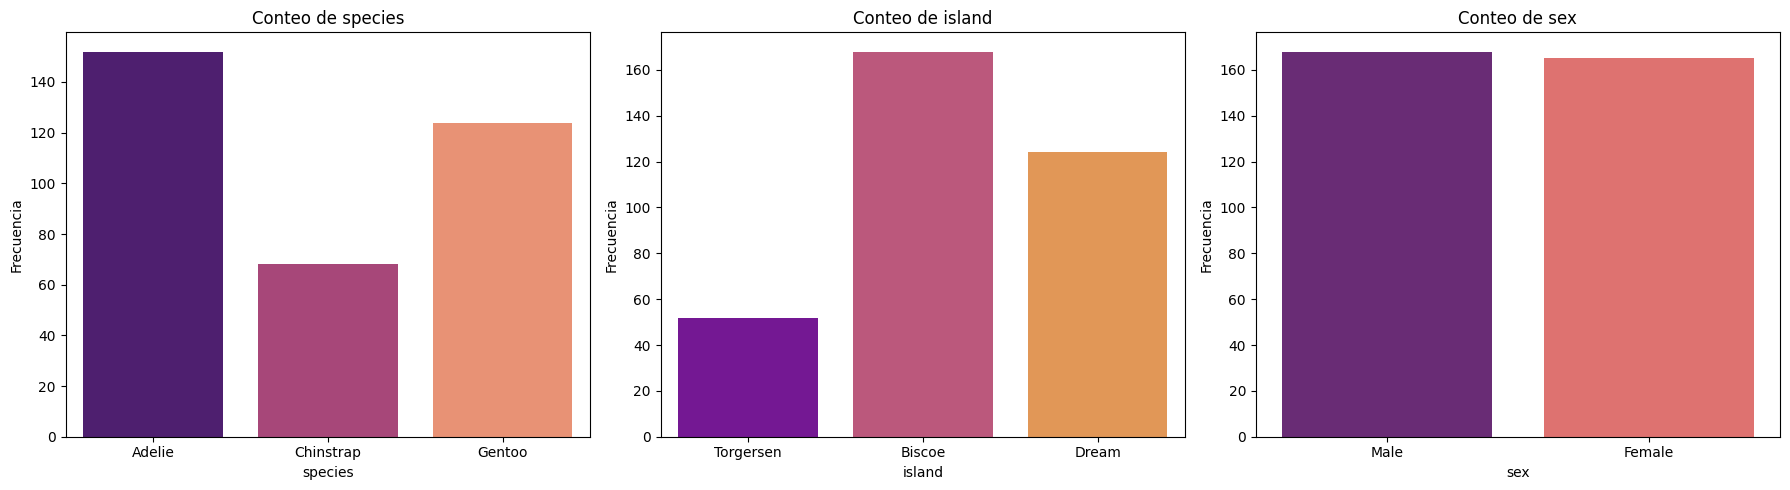

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables categóricas de baja cardinalidad
categoricas = ['species', 'island', 'sex']

paletas = ['magma', 'plasma', 'magma']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(categoricas):
    sns.countplot(data=df, x=col, hue=col, ax=axes[idx], palette=paletas[idx], legend=False)
    axes[idx].set_title(f'Conteo de {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Interpretación de los gráficos de conteo:**
- La especie Adelie es la más abundante en el dataset, seguida de Gentoo y Chinstrap.
- La isla Biscoe concentra la mayor cantidad de pingüinos, lo que puede influir en los análisis posteriores.
- La variable `sex` muestra una distribución equilibrada entre machos y hembras, aunque existen valores faltantes.
- Estos gráficos permiten identificar desbalances en la muestra y ayudan a contextualizar los resultados de los análisis estadísticos y visuales.

## 11) Histogramas para variables numéricas y descripción de su forma
**Explicación:**
Los histogramas permiten visualizar la distribución de cada variable numérica, identificando la forma (simétrica, sesgada, bimodal), la presencia de valores atípicos y la concentración de datos.
A continuación, se muestra cómo generar histogramas para todas las variables numéricas del dataset.

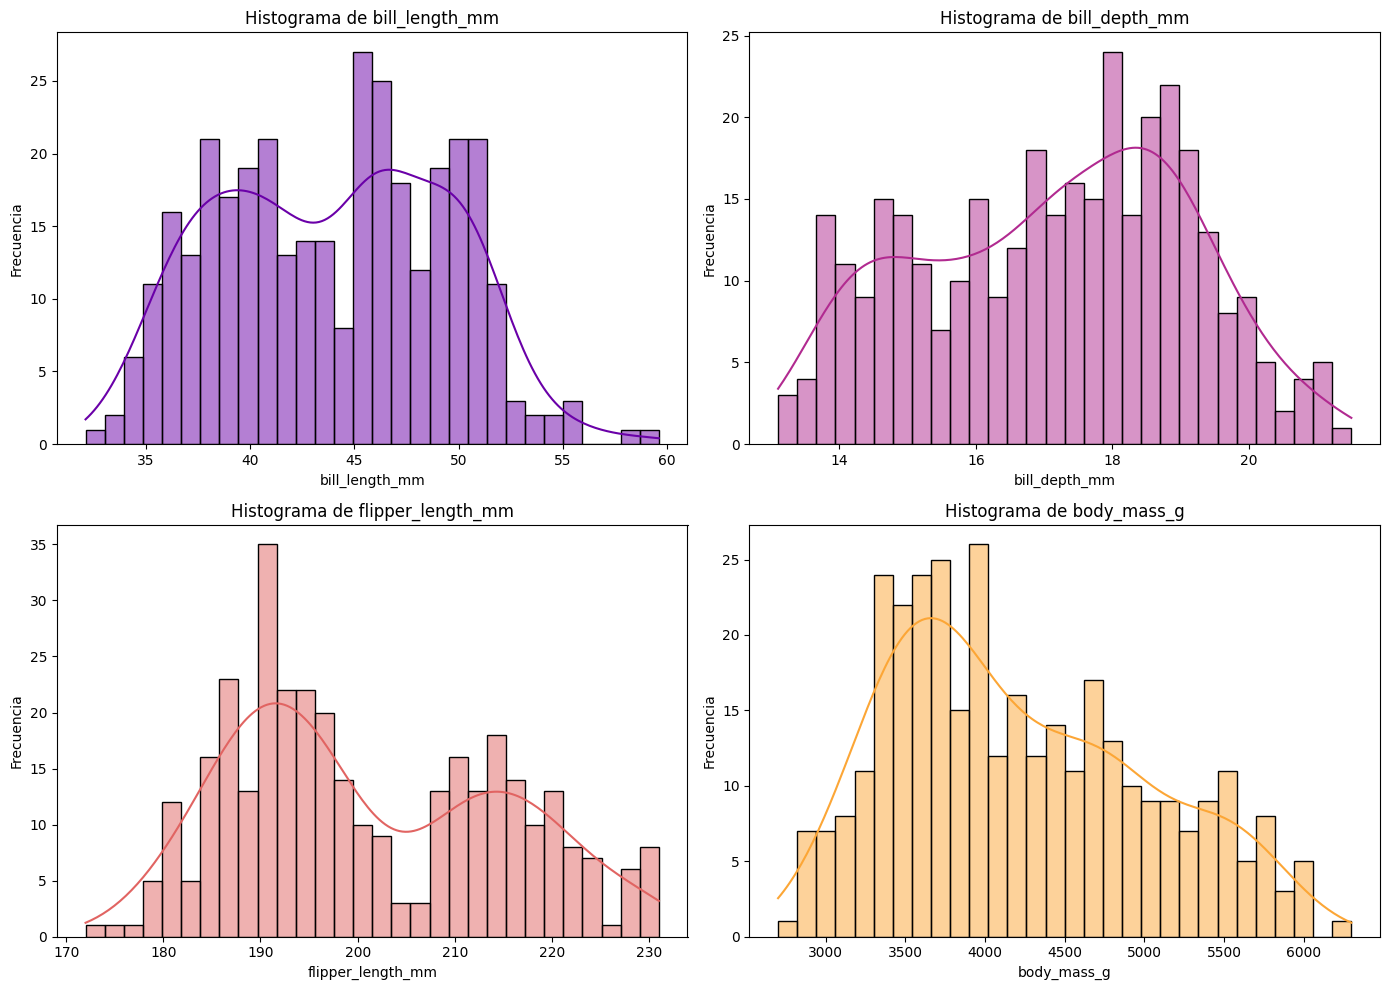

In [10]:
# Histogramas para variables numéricas (bins ajustado a 20 para mejor visualización)
numeric_cols = df.select_dtypes(include='number').columns
paleta_hist = sns.color_palette('plasma', len(numeric_cols))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, color=paleta_hist[idx], ax=axes[idx])
    axes[idx].set_title(f'Histograma de {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Interpretación de los histogramas:**
- Las variables numéricas muestran distribuciones mayormente simétricas, con la mayoría de los valores agrupados cerca de la media.
- `bill_length_mm` y `flipper_length_mm` presentan distribuciones normales, aunque pueden existir algunos valores atípicos en los extremos.
- `body_mass_g` muestra una dispersión mayor, pero sin sesgo evidente.
- `bill_depth_mm` tiene una distribución concentrada y simétrica.
- No se observan bimodalidades ni sesgos marcados, lo que sugiere que los datos son adecuados para análisis estadísticos clásicos.
- Los histogramas permiten identificar visualmente la forma de las distribuciones y posibles valores extremos que podrían requerir atención en etapas posteriores.

## 12) Boxplots para variables numéricas por categoría
**Explicación:**
Los boxplots permiten visualizar la distribución, mediana, rango intercuartílico y posibles valores atípicos de una variable numérica según una variable categórica. Son útiles para comparar grupos y detectar diferencias entre categorías como especie, isla o sexo.
A continuación, se muestra cómo generar boxplots para las variables numéricas del dataset de pingüinos, agrupando por especie, isla y sexo.

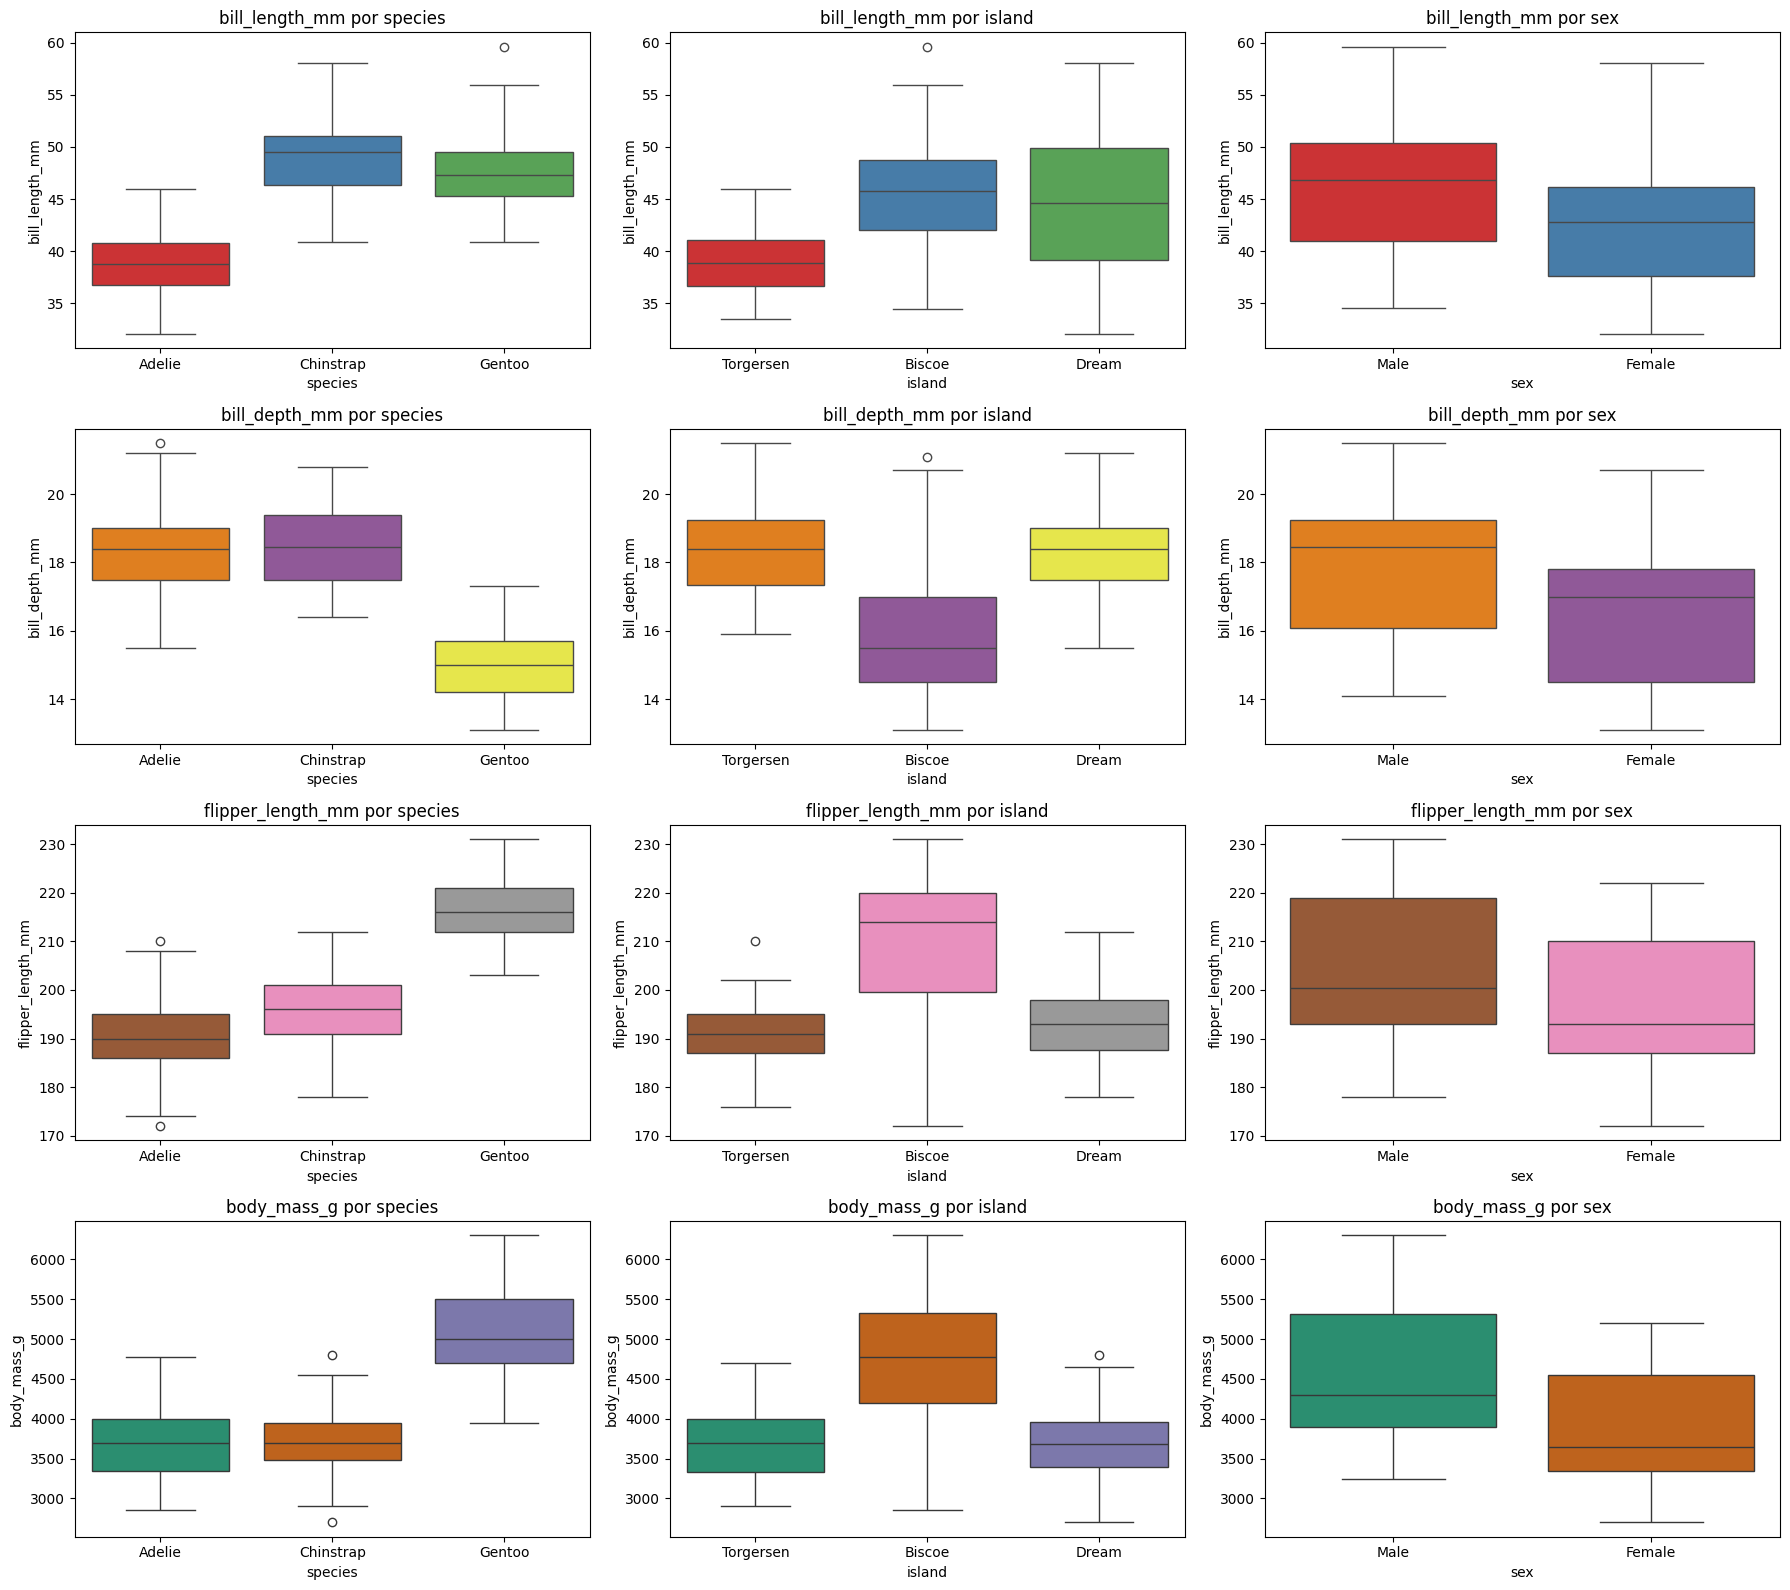

In [11]:
# Boxplots para variables numéricas por especie, isla y sexo (paletas personalizadas, adaptadas al número de categorías)
numeric_cols = df.select_dtypes(include='number').columns
categoricas = ['species', 'island', 'sex']
paletas = [
    ['#E41A1C', '#377EB8', '#4DAF4A'],  # Rojo, azul, verde
    ['#FF7F00', '#984EA3', '#FFFF33'],  # Naranja, morado, amarillo
    ['#A65628', '#F781BF', '#999999'],  # Marrón, rosa, gris
    ['#1B9E77', '#D95F02', '#7570B3']   # Verde, naranja, azul
 ]
fig, axes = plt.subplots(len(numeric_cols), len(categoricas), figsize=(18, 16))
for i, num_col in enumerate(numeric_cols):
    for j, cat_col in enumerate(categoricas):
        categorias_unicas = df[cat_col].dropna().unique()
        paleta_actual = paletas[i][:len(categorias_unicas)]
        sns.boxplot(data=df, x=cat_col, y=num_col, hue=cat_col, palette=paleta_actual, ax=axes[i, j], legend=False)
        axes[i, j].set_title(f'{num_col} por {cat_col}')
        axes[i, j].set_xlabel(cat_col)
        axes[i, j].set_ylabel(num_col)
plt.tight_layout()
plt.show()

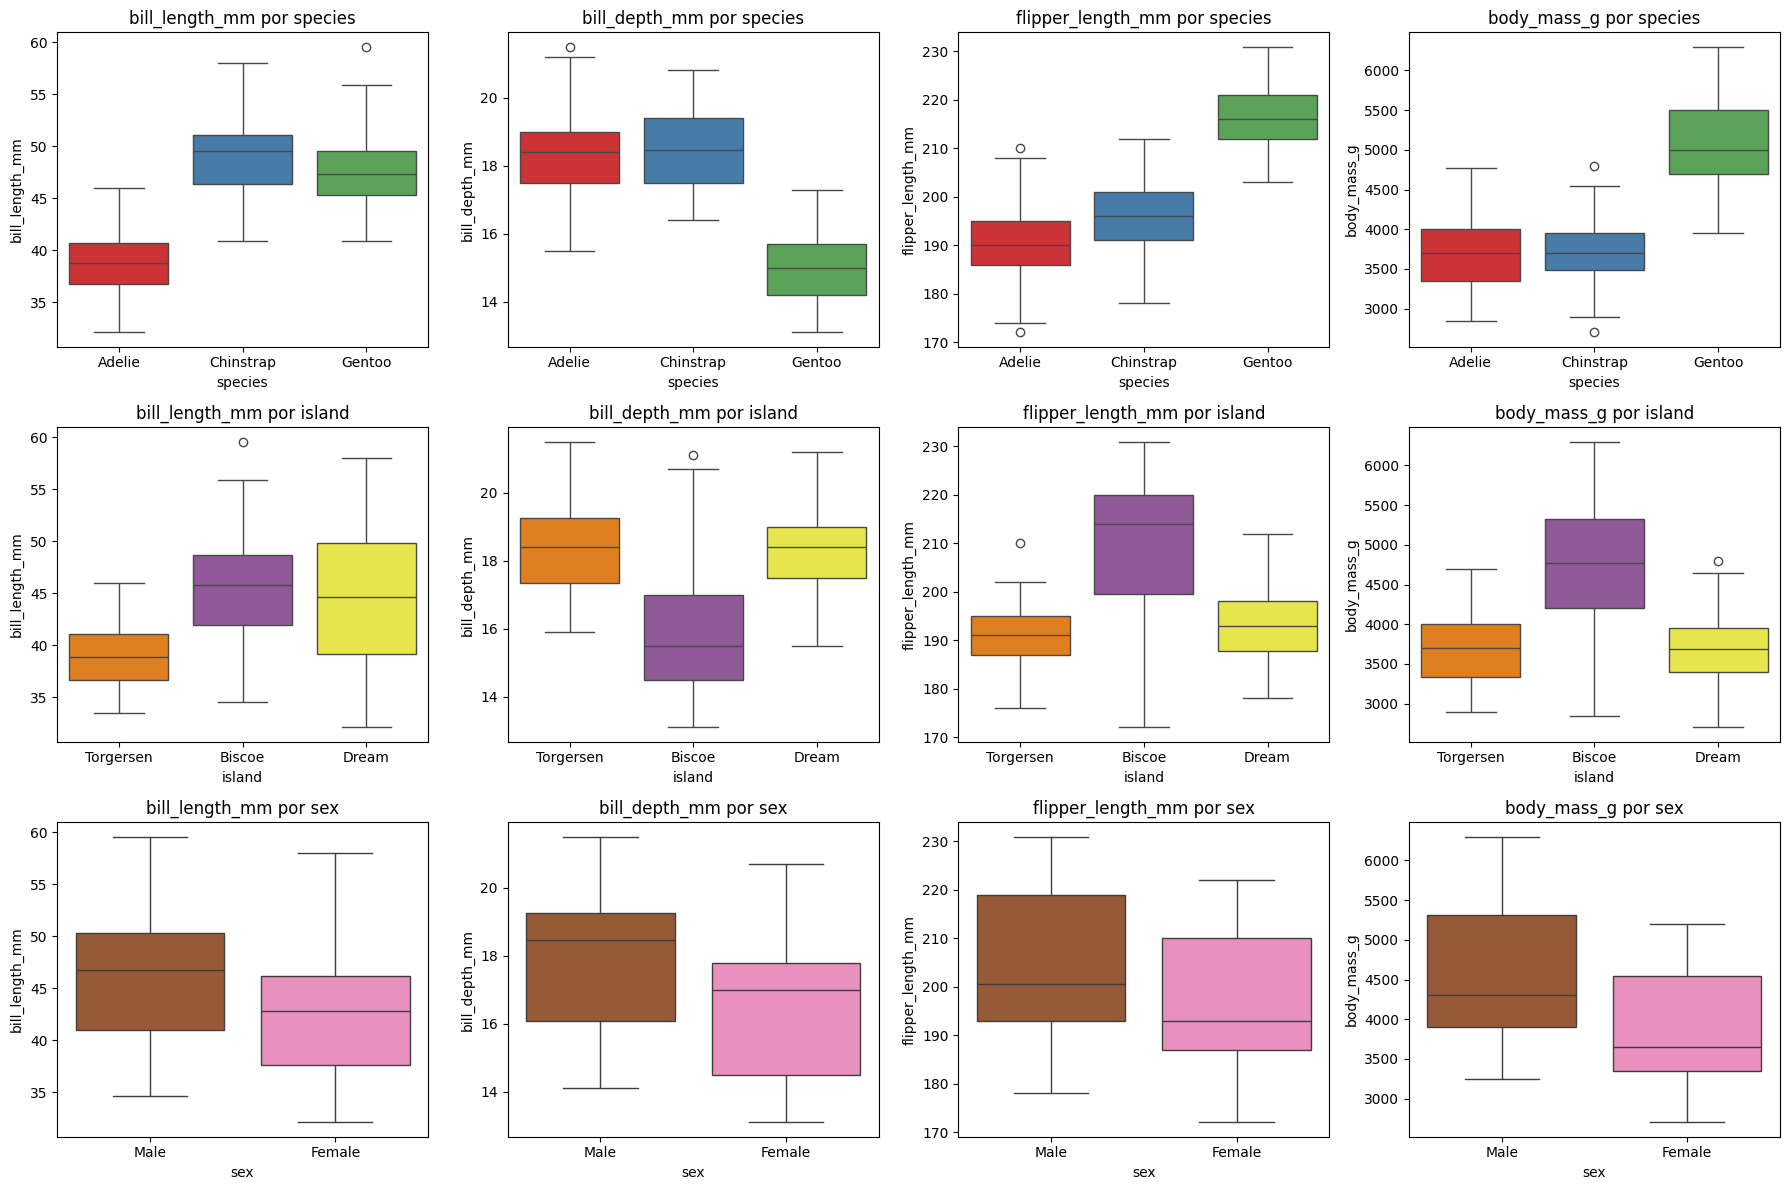

In [12]:
# Boxplots por variable categórica: cada columna tiene su propia paleta personalizada
numeric_cols = df.select_dtypes(include='number').columns
categoricas = ['species', 'island', 'sex']
paletas_cat = [
    ['#E41A1C', '#377EB8', '#4DAF4A'],  # Rojo, azul, verde para species
    ['#FF7F00', '#984EA3', '#FFFF33'],  # Naranja, morado, amarillo para island
    ['#A65628', '#F781BF']             # Marrón, rosa para sex
 ]
fig, axes = plt.subplots(len(categoricas), len(numeric_cols), figsize=(18, 12))
for i, cat_col in enumerate(categoricas):
    categorias_unicas = df[cat_col].dropna().unique()
    paleta_actual = paletas_cat[i][:len(categorias_unicas)]
    for j, num_col in enumerate(numeric_cols):
        sns.boxplot(data=df, x=cat_col, y=num_col, hue=cat_col, palette=paleta_actual, ax=axes[i, j], legend=False)
        axes[i, j].set_title(f'{num_col} por {cat_col}')
        axes[i, j].set_xlabel(cat_col)
        axes[i, j].set_ylabel(num_col)
plt.tight_layout()
plt.show()

**Interpretación de los boxplots:**
- Los boxplots permiten comparar la distribución de cada variable numérica entre categorías de especie, isla y sexo.
- Se observan diferencias claras en la longitud y profundidad del pico entre especies, lo que puede estar relacionado con la adaptación ecológica.
- La masa corporal y la longitud de la aleta también varían entre islas y sexos, aunque las diferencias entre sexos suelen ser menos marcadas.
- Los valores atípicos (outliers) aparecen como puntos fuera de las cajas, indicando casos extremos que pueden requerir análisis adicional.
- En general, los boxplots muestran que la variabilidad dentro de cada grupo es menor que la variabilidad entre grupos, lo que sugiere que las categorías tienen un efecto importante sobre las variables numéricas.
- Estas visualizaciones ayudan a identificar patrones, diferencias y posibles factores explicativos en el dataset de pingüinos.

## 13) Scatterplots para explorar relaciones entre variables numéricas


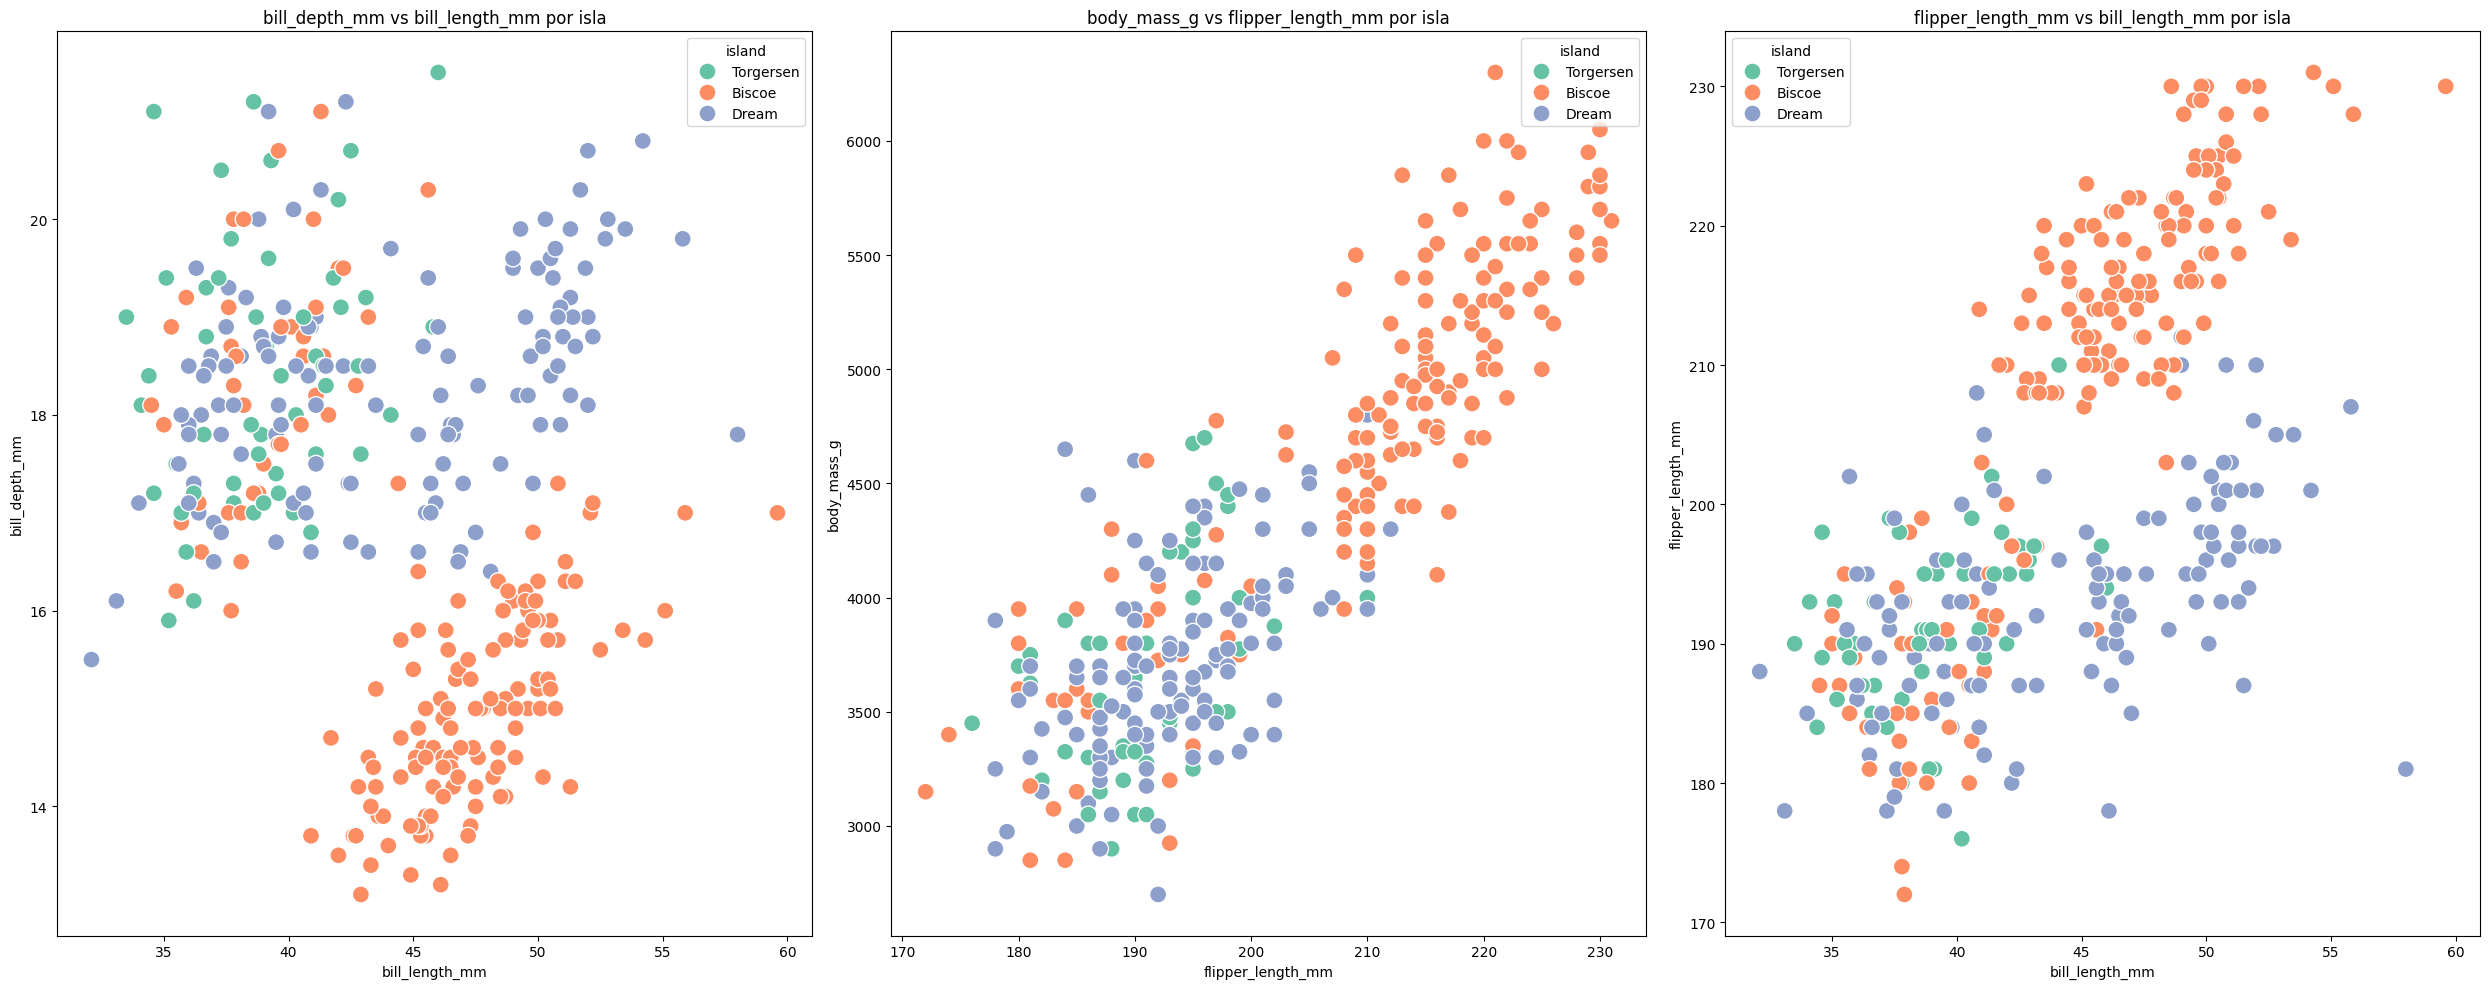

In [13]:
# Scatterplots para pares de variables numéricas, diferenciando por isla
pares = [("bill_length_mm", "bill_depth_mm"), ("flipper_length_mm", "body_mass_g"), ("bill_length_mm", "flipper_length_mm")]
fig, axes = plt.subplots(1, len(pares), figsize=(25, 10))
for idx, (x, y) in enumerate(pares):
    sns.scatterplot(data=df, x=x, y=y, hue="island", palette="Set2", ax=axes[idx],s=150)
    axes[idx].set_title(f'{y} vs {x} por isla')
    axes[idx].set_xlabel(x)
    axes[idx].set_ylabel(y)
plt.tight_layout()
plt.show()

### Interpretación de los scatterplots por isla
Los scatterplots muestran cómo se relacionan las variables numéricas entre sí, diferenciando por isla. Se observa que los pingüinos de la isla Biscoe tienden a agruparse en rangos más altos de longitud de aleta y masa corporal, mientras que los de Dream y Torgersen presentan valores más bajos en estas variables. Además, la relación entre la longitud y la profundidad del pico varía según la isla, lo que sugiere posibles adaptaciones morfológicas a las condiciones ambientales de cada ubicación. Estos patrones indican que la isla de origen es un factor relevante en la variabilidad morfológica de los pingüinos, posiblemente asociado a diferencias ecológicas o de recursos disponibles en cada isla.

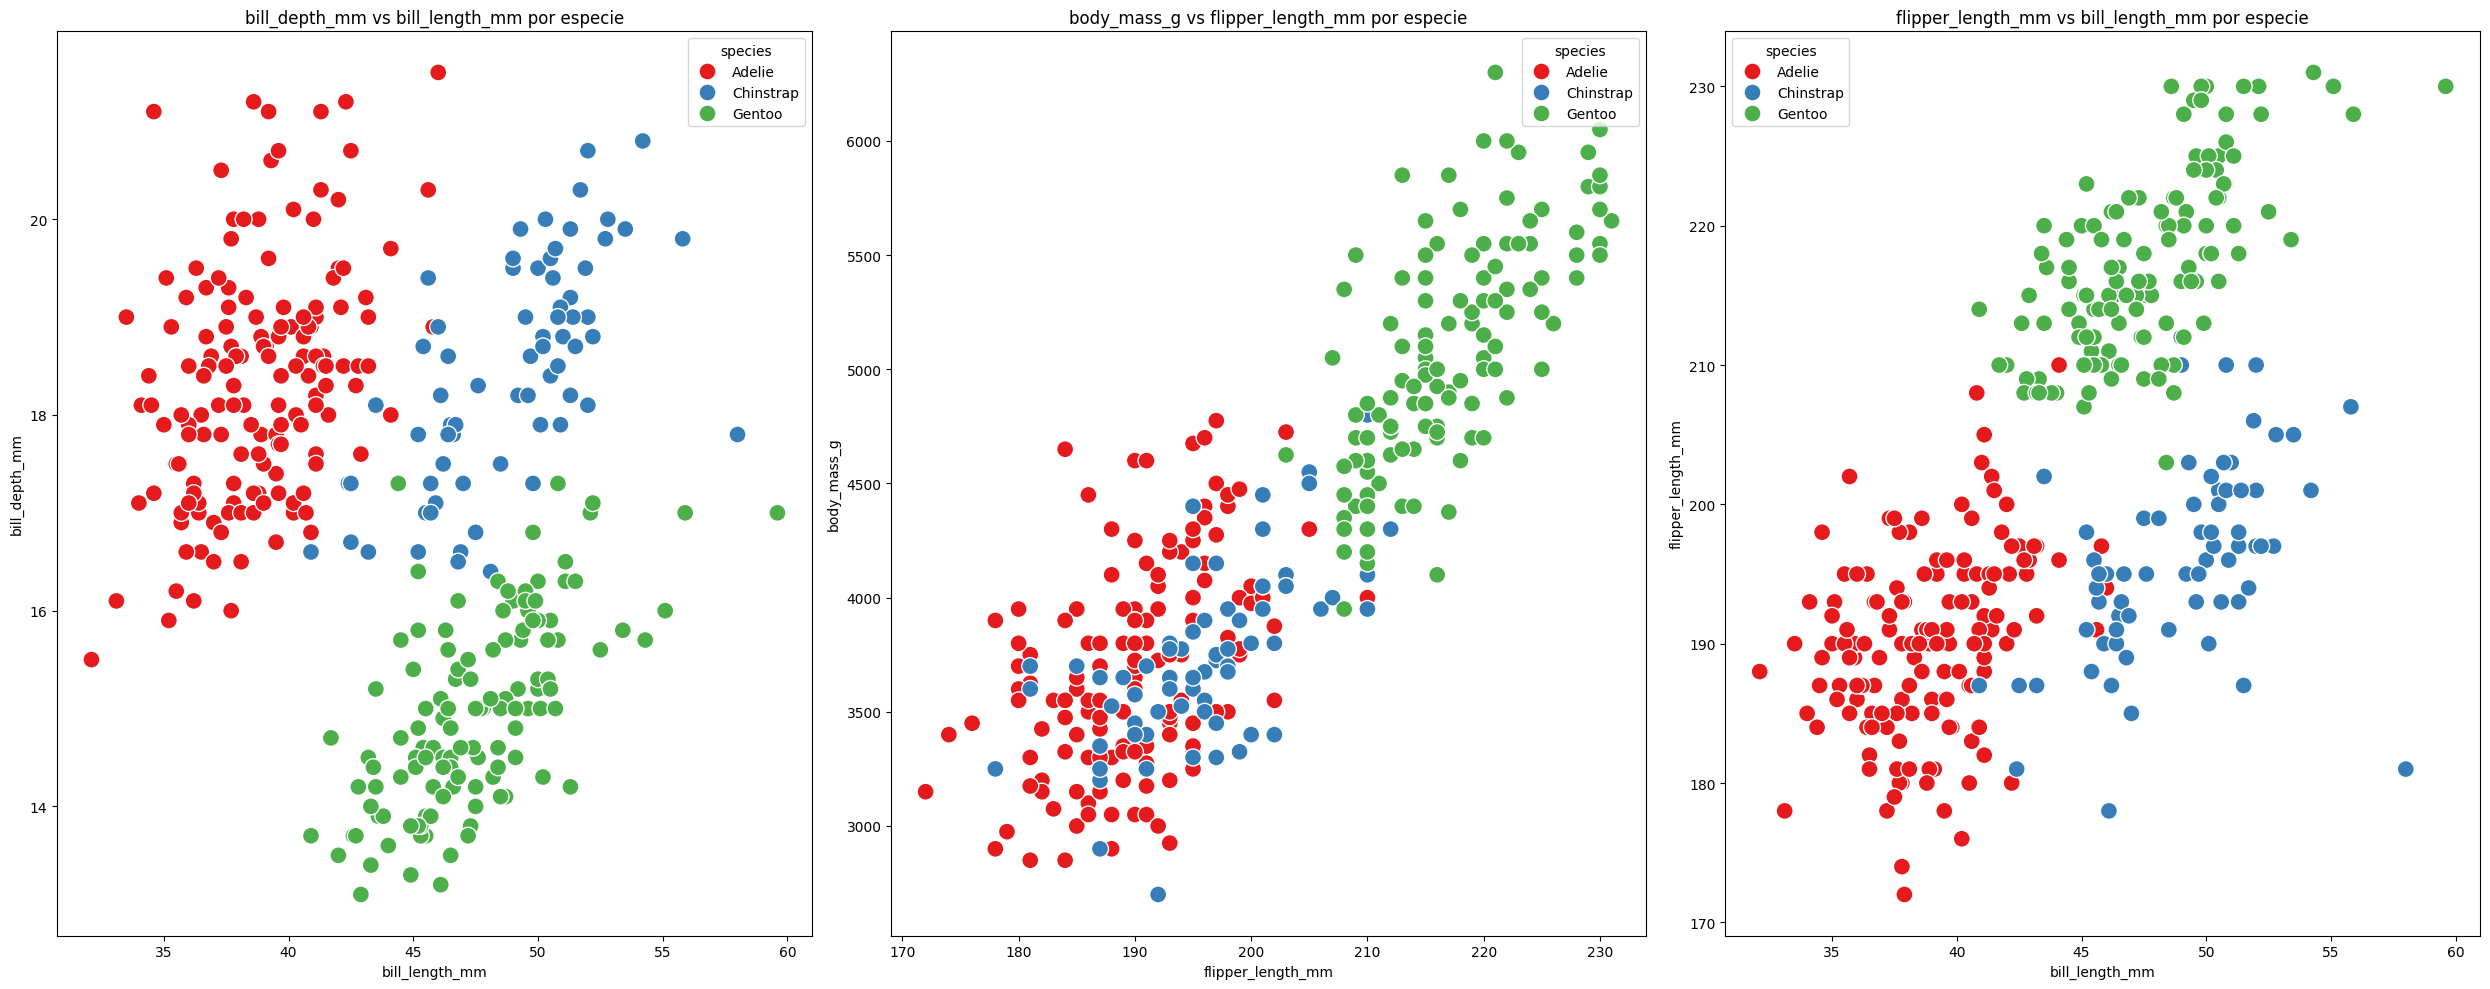

In [14]:
# Scatterplots por especie con puntos grandes y figsize (30,10)
pares = [("bill_length_mm", "bill_depth_mm"), ("flipper_length_mm", "body_mass_g"), ("bill_length_mm", "flipper_length_mm")]
fig, axes = plt.subplots(1, len(pares), figsize=(25, 10))
for idx, (x, y) in enumerate(pares):
    sns.scatterplot(data=df, x=x, y=y, hue="species", palette="Set1", ax=axes[idx], s=150)
    axes[idx].set_title(f'{y} vs {x} por especie')
    axes[idx].set_xlabel(x)
    axes[idx].set_ylabel(y)
plt.tight_layout()
plt.show()

### Interpretación de los scatterplots por especie

Los scatterplots muestran cómo se relacionan las variables numéricas entre sí, diferenciando por especie. Se observa que cada especie de pingüino tiende a agruparse en regiones distintas del espacio de variables, lo que indica diferencias morfológicas claras entre ellas. Por ejemplo, la especie Gentoo suele presentar mayor longitud de aleta y masa corporal, mientras que Adelie y Chinstrap se agrupan en rangos más bajos para estas variables. Además, la relación entre longitud y profundidad del pico también varía entre especies, reflejando adaptaciones ecológicas específicas. Estas visualizaciones permiten identificar patrones de separación entre especies y sugieren que la especie es un factor determinante en la variabilidad morfológica de los pingüinos.

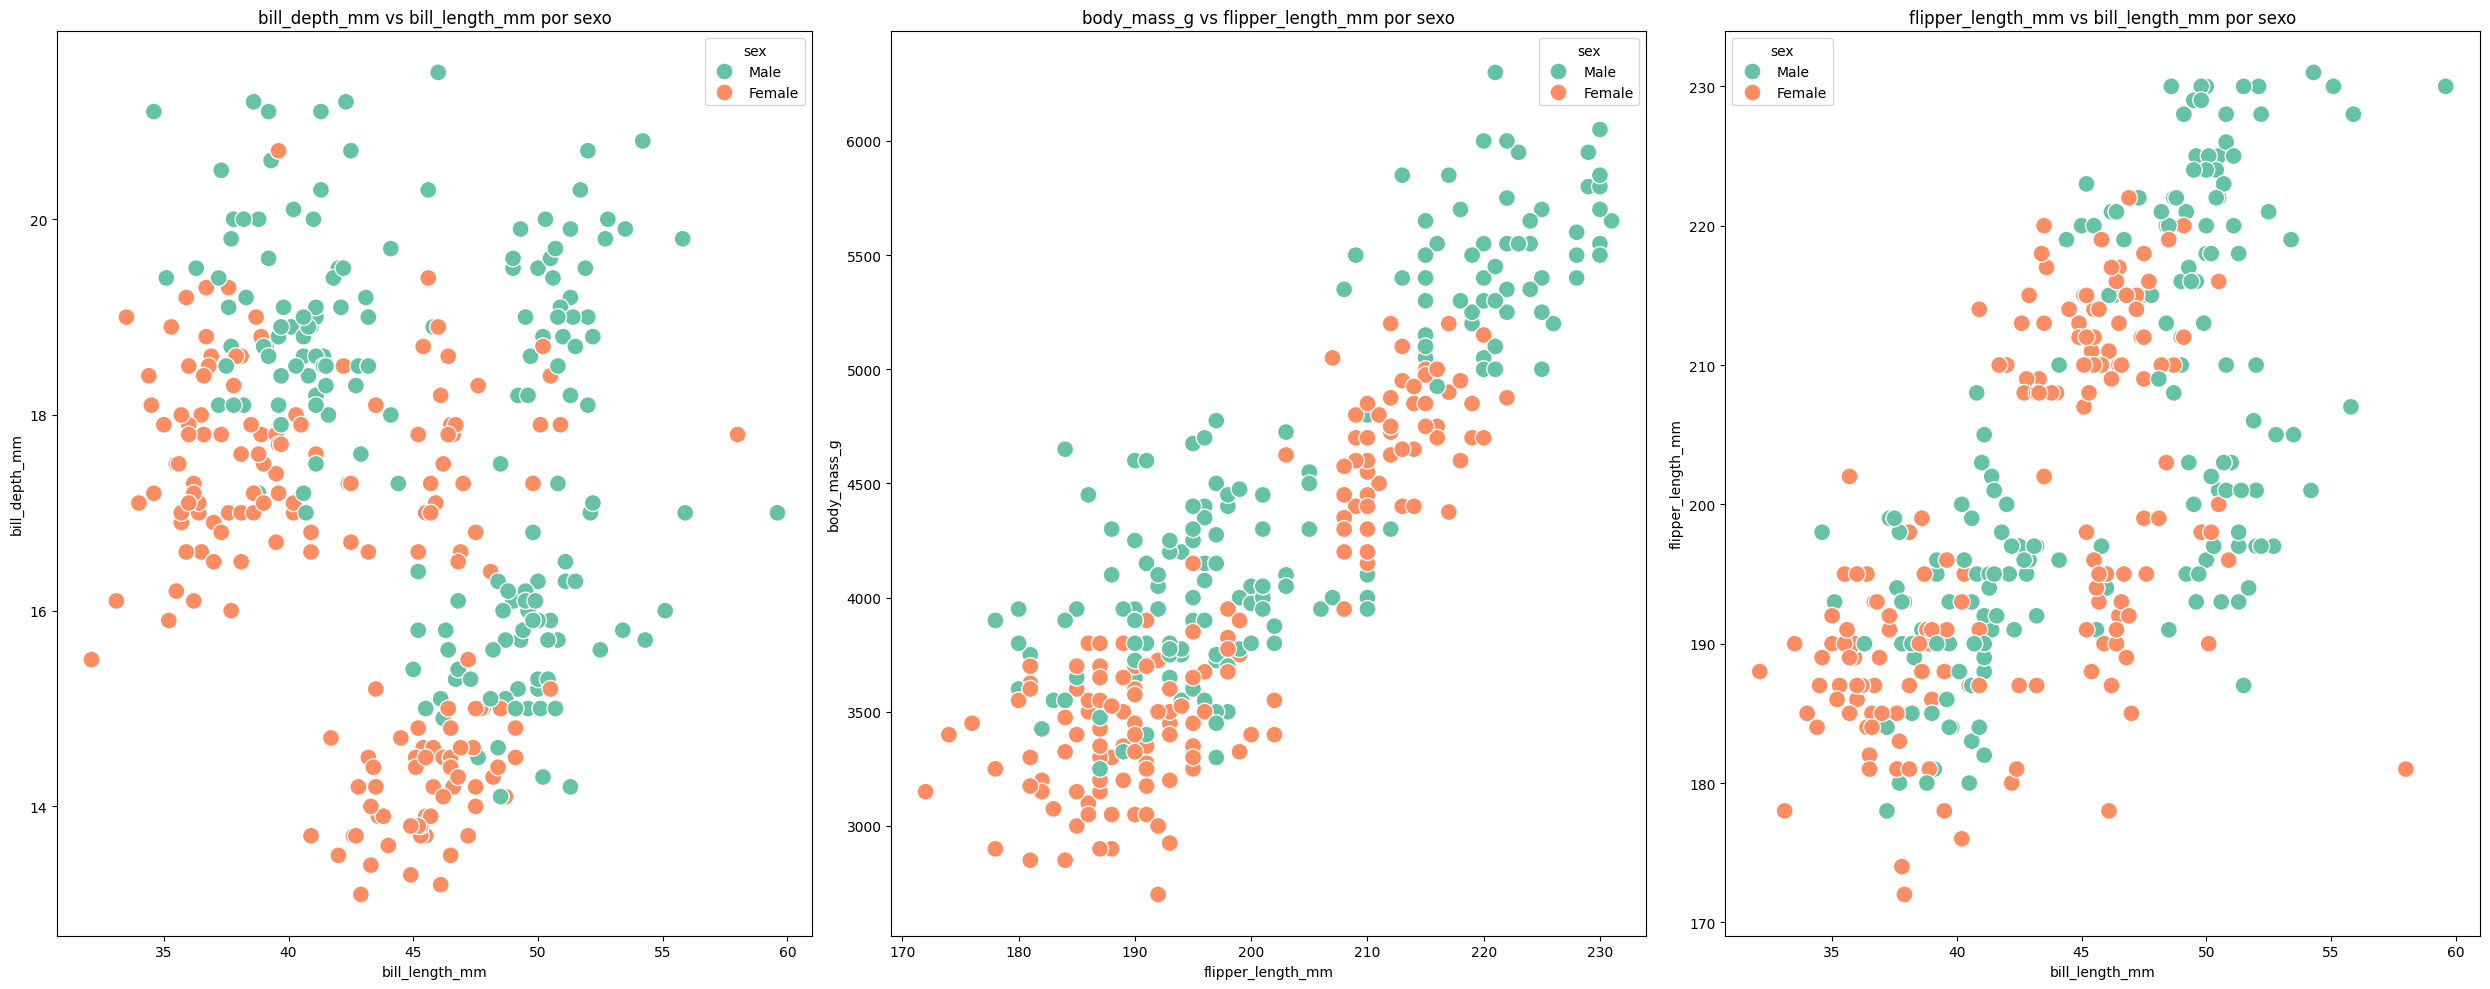

In [15]:
# Scatterplots para pares de variables numéricas, diferenciando por sexo
pares = [("bill_length_mm", "bill_depth_mm"), ("flipper_length_mm", "body_mass_g"), ("bill_length_mm", "flipper_length_mm")]
fig, axes = plt.subplots(1, len(pares), figsize=(25, 10))
for idx, (x, y) in enumerate(pares):
    sns.scatterplot(data=df, x=x, y=y, hue="sex", palette="Set2", ax=axes[idx],s=150)
    axes[idx].set_title(f'{y} vs {x} por sexo')
    axes[idx].set_xlabel(x)
    axes[idx].set_ylabel(y)
plt.tight_layout()
plt.show()

### Interpretación de los scatterplots por sexo
Los scatterplots muestran cómo se relacionan las variables numéricas entre sí, diferenciando por sexo. Se aprecia que, en general, los machos tienden a presentar valores ligeramente superiores en masa corporal y longitud de aleta en comparación con las hembras, aunque existe un solapamiento considerable en los rangos de ambas categorías. La relación entre longitud y profundidad del pico también muestra diferencias sutiles entre sexos, pero no tan marcadas como las observadas entre especies o islas. Estas visualizaciones sugieren que el sexo influye en algunas características morfológicas, aunque la variabilidad dentro de cada grupo es significativa y los rangos suelen solaparse.

## Heatmaps de correlaciones: Pearson y Spearman
**Explicación:**
Los heatmaps permiten visualizar de forma intuitiva la matriz de correlación entre variables numéricas. Se presentan dos mapas: uno con correlaciones de Pearson (relaciones lineales) y otro con Spearman (relaciones monótonas). Comparar ambos ayuda a identificar si las asociaciones son lineales o si hay efectos de valores atípicos o relaciones no estrictamente lineales.
A continuación, se muestran ambos heatmaps para las variables numéricas del dataset.

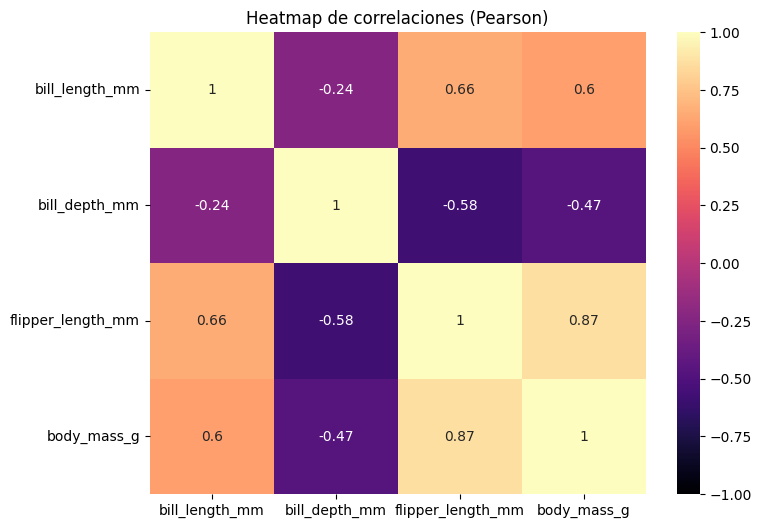

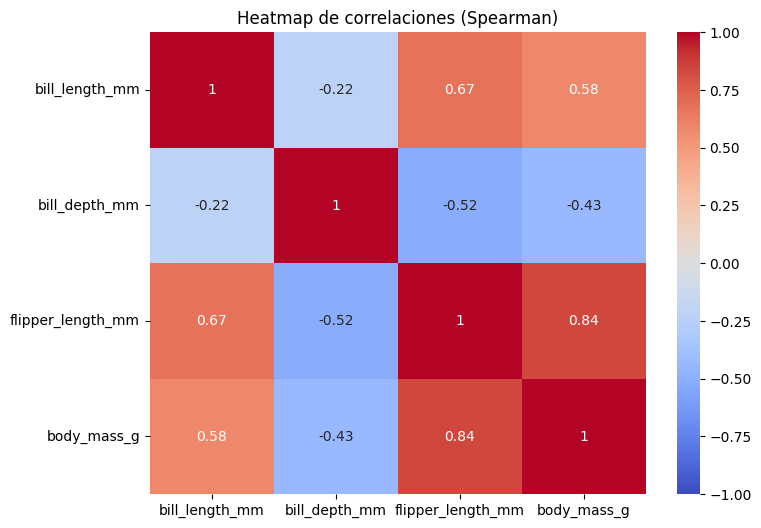

In [16]:
# Heatmap de correlaciones de Pearson
numeric_cols = df.select_dtypes(include='number').columns
pearson_corr = df[numeric_cols].corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='magma', vmin=-1, vmax=1)
plt.title('Heatmap de correlaciones (Pearson)')
plt.show()

# Heatmap de correlaciones de Spearman
spearman_corr = df[numeric_cols].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap de correlaciones (Spearman)')
plt.show()

### Interpretación y conclusiones de los heatmaps
- **Pearson:** El heatmap de Pearson muestra relaciones lineales entre variables numéricas. Se observa una fuerte correlación positiva entre `flipper_length_mm` y `body_mass_g`, lo que indica que los pingüinos con aletas más largas tienden a tener mayor masa corporal. Las demás variables presentan correlaciones moderadas o bajas, lo que sugiere que cada variable aporta información distinta.
- **Spearman:** El heatmap de Spearman muestra relaciones monótonas, incluyendo posibles efectos de valores atípicos. Los patrones son muy similares a los de Pearson, lo que indica que las relaciones entre variables son principalmente lineales y no están influenciadas por outliers.
- **Diferencias:** Las diferencias entre ambos métodos son mínimas, lo que refuerza la robustez de los resultados y sugiere que no hay relaciones no lineales ni valores atípicos que afecten significativamente las correlaciones.
En conclusión, los resultados de ambos heatmaps permiten interpretar las asociaciones con confianza y sugieren que los hallazgos no dependen del método de correlación elegido.

# Parte D y E — Hipótesis falsables y Pruebas estadisticas 

A continuación se presentan tres hipótesis falsables basadas en los gráficos y descripciones previas. Cada hipótesis incluye explicación, código para la prueba y una conclusión interpretativa.

## Hipótesis 1: Diferencia en longitud del pico entre islas

Hipótesis: La longitud del pico (bill_length_mm) difiere significativamente entre pingüinos de distintas islas.

In [17]:
# Prueba t para comparar la longitud del pico entre islas Biscoe y Dream
biscoe = df[df['island']=='Biscoe']['bill_length_mm'].dropna()
dream = df[df['island']=='Dream']['bill_length_mm'].dropna()
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(biscoe, dream)
print(f"Media Biscoe: {biscoe.mean():.2f}")
print(f"Media Dream: {dream.mean():.2f}")
print(f"t = {t_stat:.2f}, p = {p_value:.4f}")

Media Biscoe: 45.26
Media Dream: 44.17
t = 1.73, p = 0.0843


**Conclusión:**

La prueba t compara la longitud promedio del pico entre pingüinos de las islas Biscoe y Dream. Si el valor p es menor a 0.05, se rechaza la hipótesis nula y se concluye que existe una diferencia significativa entre las islas. Si el valor p es mayor, no hay evidencia suficiente para afirmar que la diferencia es significativa.

## Hipótesis 2: Diferencia de masa corporal entre sexos

Hipótesis: La masa corporal (body_mass_g) difiere significativamente entre pingüinos machos y hembras.

In [18]:
# Prueba t para comparar la masa corporal entre sexos
male = df[df['sex']=='Male']['body_mass_g'].dropna()
female = df[df['sex']=='Female']['body_mass_g'].dropna()
t_stat, p_value = ttest_ind(male, female)
print(f"Media machos: {male.mean():.2f}")
print(f"Media hembras: {female.mean():.2f}")
print(f"t = {t_stat:.2f}, p = {p_value:.4f}")

Media machos: 4545.68
Media hembras: 3862.27
t = 8.54, p = 0.0000


**Conclusión:**

La prueba t compara la masa corporal promedio entre pingüinos machos y hembras. Si el valor p es menor a 0.05, se rechaza la hipótesis nula y se concluye que existe una diferencia significativa entre los sexos. Si el valor p es mayor, no hay evidencia suficiente para afirmar que la diferencia es significativa.

## Hipótesis 3: Fuerza de correlación entre longitud de aleta y masa corporal según especie

Hipótesis: La fuerza de la correlación entre la longitud de la aleta (flipper_length_mm) y la masa corporal (body_mass_g) difiere entre las especies de pingüinos.

In [19]:
# Correlación de flipper_length_mm y body_mass_g por especie
from scipy.stats import pearsonr
resultados = {}
for especie in df['species'].unique():
    sub = df[df['species']==especie][['flipper_length_mm','body_mass_g']].dropna()
    r, p = pearsonr(sub['flipper_length_mm'], sub['body_mass_g'])
    resultados[especie] = {'r': r, 'p': p}
for especie, res in resultados.items():
    print(f"{especie}: r = {res['r']:.2f}, p = {res['p']:.4f}")

Adelie: r = 0.47, p = 0.0000
Chinstrap: r = 0.64, p = 0.0000
Gentoo: r = 0.70, p = 0.0000


**Conclusión:**

Se calcula el coeficiente de correlación de Pearson entre la longitud de la aleta y la masa corporal para cada especie. Si el valor p es menor a 0.05, la correlación es significativa. Si los valores de r difieren notablemente entre especies, se confirma la hipótesis de que la fuerza de la relación varía según la especie.

# Parte F — Conclusiones y reporte

En esta sección se presentan las conclusiones del análisis realizado sobre el dataset de pingüinos, organizadas en tres capas: hallazgos descriptivos, patrones visuales y próximas hipótesis a probar. Además, se incluyen preguntas abiertas para un investigador humano.

## A) Hallazgos descriptivos (con evidencia)
- El dataset contiene 344 observaciones y 7 variables, con valores faltantes principalmente en la variable `sex`.
- Las variables numéricas presentan distribuciones mayormente simétricas, sin sesgos marcados ni bimodalidades.
- Existen diferencias claras en las características morfológicas entre especies e islas, evidenciadas por los resúmenes estadísticos y las tablas cruzadas.
- La correlación más fuerte se observa entre la longitud de la aleta (`flipper_length_mm`) y la masa corporal (`body_mass_g`).

## B) Patrones visuales (con evidencia)
- Los gráficos de conteo muestran que la especie Adelie y la isla Biscoe son las más representadas en la muestra.
- Los boxplots y scatterplots revelan que las especies y las islas agrupan a los pingüinos en regiones morfológicas distintas, sugiriendo adaptación ecológica.
- Los machos tienden a tener mayor masa corporal y longitud de aleta que las hembras, aunque los rangos se solapan.
- Los heatmaps de correlación confirman la robustez de las asociaciones entre variables numéricas.

## C) Próximas hipótesis a probar
- ¿Existen diferencias morfológicas significativas entre pingüinos de diferentes años o cohortes, si se dispone de esa información?
- ¿Cómo influyen factores ambientales externos (temperatura, alimento) en la morfología de los pingüinos?
- ¿Se pueden construir modelos predictivos robustos para clasificar especies o sexos a partir de variables morfológicas?

## Preguntas para un investigador humano
- ¿Cómo se manejaron los valores faltantes en la variable `sex` durante la recolección de datos?
- ¿Existen posibles sesgos de muestreo en la representación de especies o islas?
- ¿Sería relevante controlar por edad o estado reproductivo en futuros análisis?
- ¿Qué variables adicionales serían útiles para profundizar en el estudio de la variabilidad morfológica de los pingüinos?

Estas conclusiones y preguntas buscan sintetizar los hallazgos y abrir nuevas líneas de investigación, promoviendo un análisis riguroso y fundamentado en la evidencia obtenida.